# Hemodynamic Model Experiment

What's the impact of the choice of Heamodynamic model on the simulated FC, with the same set of parameters.

In [158]:
import numpy as np
import matplotlib.pyplot as plt
from hbnm.io import Data
from hbnm.bnm import Bnm
import pandas as pd
import h5py
from hbnm.model.utils import subdiag, fisher_z
from scipy.stats import pearsonr

In [159]:
# Load the data
data_handler = Data("/Users/fdjim/Desktop/HBNM/HBNM/data/", "hemodynamic_experiments_outputs/")

fin = data_handler.load('demirtas_neuron_2019.hdf5', from_output=False)
theta_heterogeneous = fin['apprx_posterior_heterogeneous'][:]
theta_homogeneous = fin['apprx_posterior_homogeneous'][:]
fin.close()

sc, hmap, fc_obj = data_handler.load_demirtas_neuron_2019_data()

In [161]:
# Define matrix plotting function

def matrix_plot(ax, x, cmap):
    im = ax.pcolormesh(x, cmap=cmap, vmin=x.min(), vmax=x.max())
    ax.set_aspect(1)
    ax.set_xlim([0, x.shape[1]])
    ax.set_ylim([0, x.shape[0]])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    return im  # Return this so you can add colorbar later


## Using linearization

Using Obtata BOLD model

In [160]:
# Create model and set parameters
heterogeneous = Bnm(sc, gradient=hmap, bold_params='obata')
heterogeneous.set('w_EI', (theta_heterogeneous[0,0], theta_heterogeneous[1,0]))
heterogeneous.set('w_EE', (theta_heterogeneous[2,0], theta_heterogeneous[3,0]))
heterogeneous.set('G', theta_heterogeneous[4,0])
heterogeneous.moments_method()

print(pearsonr(subdiag(fc_obj), subdiag(heterogeneous.get('corr_bold'))))

PearsonRResult(statistic=np.float64(0.5685560002780502), pvalue=np.float64(0.0))


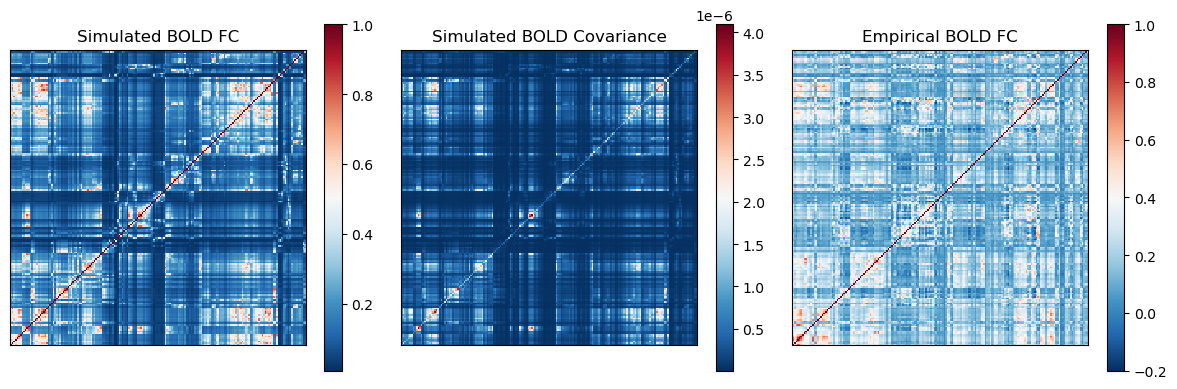

In [162]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

im1 = matrix_plot(ax1, heterogeneous.get('corr_bold'), 'RdBu_r')
ax1.set_title('Simulated BOLD FC')
plt.colorbar(im1, ax=ax1)

im2 = matrix_plot(ax2, heterogeneous.get('cov_bold'), 'RdBu_r')
ax2.set_title('Simulated BOLD Covariance')
plt.colorbar(im2, ax=ax2)

im3 = matrix_plot(ax3, fc_obj, 'RdBu_r')
ax3.set_title('Empirical BOLD FC')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()

Using Friston BOLD model

In [163]:
# Create model and set parameters
model_friston_bold = Bnm(sc, gradient=hmap, bold_params='friston')
model_friston_bold.set('w_EI', (theta_heterogeneous[0,0], theta_heterogeneous[1,0]))
model_friston_bold.set('w_EE', (theta_heterogeneous[2,0], theta_heterogeneous[3,0]))
model_friston_bold.set('G', theta_heterogeneous[4,0])
model_friston_bold.moments_method()

print(pearsonr(subdiag(fc_obj), subdiag(model_friston_bold.get('corr_bold'))))

PearsonRResult(statistic=np.float64(0.568550370816985), pvalue=np.float64(0.0))


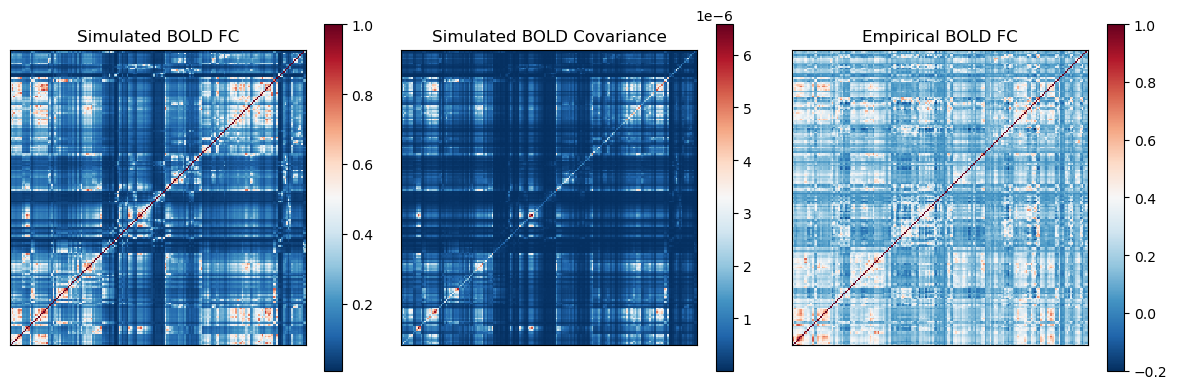

In [164]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

im1 = matrix_plot(ax1, model_friston_bold.get('corr_bold'), 'RdBu_r')
ax1.set_title('Simulated BOLD FC')
plt.colorbar(im1, ax=ax1)

im2 = matrix_plot(ax2, model_friston_bold.get('cov_bold'), 'RdBu_r')
ax2.set_title('Simulated BOLD Covariance')
plt.colorbar(im2, ax=ax2)

im3 = matrix_plot(ax3, fc_obj, 'RdBu_r')
ax3.set_title('Empirical BOLD FC')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()